# Figure S1: elastic-ratio bifurcations
$\gamma_b=-6$, $\sigma=2$, $\kappa=0.1$, $V_0=1$. Each local minimum is plotted separately.

In [1]:
# Locate the bundled simulator without requiring an editable installation.
from pathlib import Path
import sys
import tomllib

package_root = None
for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    for candidate in (parent, parent / "for_public"):
        project_file = candidate / "pyproject.toml"
        if project_file.is_file() and (candidate / "cvm3d" / "__init__.py").is_file():
            project = tomllib.loads(project_file.read_text(encoding="utf-8"))
            if project.get("project", {}).get("name") == "epithelial-cvm3d":
                package_root = candidate.resolve()
                break
    if package_root is not None:
        break

if package_root is not None:
    loaded = sys.modules.get("cvm3d")
    if (
        loaded is not None
        and Path(loaded.__file__).resolve().parent != package_root / "cvm3d"
    ):
        raise RuntimeError(
            "Another cvm3d package is loaded. Restart the kernel and run all cells."
        )
    sys.path.insert(0, str(package_root))

import jax

jax.config.update("jax_enable_x64", True)
import cvm3d


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy.optimize import brentq, minimize_scalar

SQRT3 = np.sqrt(3.0)
V0 = 1.0
KAPPA = 0.1
MM_TO_INCH = 1.0 / 25.4

sns.set_theme(
    context="paper",
    style="ticks",
    palette="colorblind",
    rc={
        "font.size": 6,
        "axes.labelsize": 5,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 4,
        "lines.linewidth": 0.75,
        "axes.linewidth": 0.5,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
    },
)
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "font.weight": "regular",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


In [3]:
def energy(l, param, *, kappa=KAPPA, V0=V0):
    gamma_b, gamma_c, sigma = param
    l = np.asarray(l)
    return (
        1.5 * SQRT3 * gamma_b * l**2
        + (2.0 * SQRT3 / 3.0) * gamma_c * V0 / l
        + 6.0 * sigma * l  # sigma P, with P = 6l
        + kappa * (32.0 / (3.0 * l**2) + 27.0 * l**4 / V0**2)
    )


def denergy_dl(l, param, *, kappa=KAPPA, V0=V0):
    gamma_b, gamma_c, sigma = param
    l = np.asarray(l)
    return (
        3.0 * SQRT3 * gamma_b * l
        - (2.0 * SQRT3 / 3.0) * gamma_c * V0 / l**2
        + 6.0 * sigma
        + kappa * (-64.0 / (3.0 * l**3) + 108.0 * l**3 / V0**2)
    )


def d2energy_dl2(l, param, *, kappa=KAPPA, V0=V0):
    gamma_b, gamma_c, _ = param
    l = np.asarray(l)
    return (
        3.0 * SQRT3 * gamma_b
        + (4.0 * SQRT3 / 3.0) * gamma_c * V0 / l**3
        + kappa * (64.0 / l**4 + 324.0 * l**2 / V0**2)
    )


def bulk_modulus(l, param, *, kappa=KAPPA, V0=V0):
    gamma_b, gamma_c, _ = param
    return (
        gamma_b / 2.0
        + 2.0 * V0 * gamma_c / (9.0 * l**3)
        + 32.0 * SQRT3 * kappa / (9.0 * l**4)
        + 18.0 * SQRT3 * kappa * l**2 / V0**2
    )


def shear_modulus(l, param, *, kappa=KAPPA, V0=V0):
    _, gamma_c, sigma = param
    return (
        V0 * gamma_c / (6.0 * l**3)
        + SQRT3 * sigma / (2.0 * l)
        + 64.0 * SQRT3 * kappa / (27.0 * l**4)
    )


def poisson_ratio(l, param):
    lam = bulk_modulus(l, param)
    mu = shear_modulus(l, param)
    return (lam - mu) / (lam + mu)


def local_minima(param, bounds=(1e-2, 8.0), samples=1600):
    grid = np.geomspace(bounds[0], bounds[1], samples)
    deriv = denergy_dl(grid, param)
    ids = np.flatnonzero(np.signbit(deriv[:-1]) != np.signbit(deriv[1:]))
    roots = [brentq(lambda l: denergy_dl(l, param), grid[i], grid[i + 1]) for i in ids]
    return np.array([l for l in roots if d2energy_dl2(l, param) > 0.0])


def global_minimum(param, bounds=(1e-4, 1e2), samples=500):
    log_grid = np.linspace(np.log(bounds[0]), np.log(bounds[1]), samples)
    values = energy(np.exp(log_grid), param)
    i = int(np.nanargmin(values))
    if i in (0, samples - 1):
        raise RuntimeError("minimum reached a search bound")
    result = minimize_scalar(
        lambda x: energy(np.exp(x), param),
        bounds=(log_grid[i - 1], log_grid[i + 1]),
        method="bounded",
        options={"xatol": 1e-11},
    )
    if not result.success:
        raise RuntimeError(result.message)
    return float(np.exp(result.x))


def phase_ticks(ax, x_values, y_values, rotate_x=0, integer_labels=False):
    if integer_labels:
        x_tick_values = np.arange(
            np.ceil(np.min(x_values)), np.floor(np.max(x_values)) + 1
        )
        y_tick_values = np.arange(
            np.ceil(np.min(y_values)), np.floor(np.max(y_values)) + 1
        )
        x_positions = np.interp(x_tick_values, x_values, np.arange(len(x_values)))
        y_positions = np.interp(y_tick_values, y_values, np.arange(len(y_values)))
        ax.set_xticks(x_positions)
        ax.set_yticks(y_positions)
        ax.set_xticklabels(
            [f"{value:.0f}" for value in x_tick_values], rotation=rotate_x
        )
        ax.set_yticklabels([f"{value:.0f}" for value in y_tick_values])
        return

    iy = np.linspace(0, len(y_values) - 1, 6).round().astype(int)
    ix = np.linspace(0, len(x_values) - 1, 6).round().astype(int)
    ax.set_yticks(iy)
    ax.set_yticklabels([f"{y_values[k]:.1f}" for k in iy])
    ax.set_xticks(ix)
    ax.set_xticklabels([f"{x_values[k]:.1f}" for k in ix], rotation=rotate_x)


In [4]:
gamma_c_scan = np.linspace(0.0, -15.0, 1001)
gamma_c_branch = []
l_branch = []
lambda_branch = []
mu_branch = []

for gamma_c in gamma_c_scan:
    param = (-6.0, gamma_c, 2.0)
    for l0 in local_minima(param, samples=4000):
        gamma_c_branch.append(gamma_c)
        l_branch.append(l0)
        lambda_branch.append(bulk_modulus(l0, param))
        mu_branch.append(shear_modulus(l0, param))

gamma_c_branch = np.asarray(gamma_c_branch)
l_branch = np.asarray(l_branch)
lambda_branch = np.asarray(lambda_branch)
mu_branch = np.asarray(mu_branch)

assert np.all(lambda_branch > 0.0) and np.all(mu_branch > 0.0)
print(f"{len(gamma_c_branch)} stable-branch points")


1397 stable-branch points


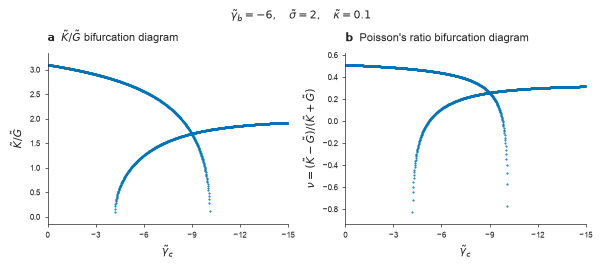

In [5]:
# Figure S1: use the same local-minimum branches as Figures 3D--F.
K_over_G_branch = lambda_branch / mu_branch
nu_branch = (lambda_branch - mu_branch) / (lambda_branch + mu_branch)

with plt.rc_context({"text.usetex": False, "axes.titlesize": 8, "axes.labelsize": 8}):
    fig_s1, axes_s1 = plt.subplots(
        1,
        2,
        figsize=(150 * MM_TO_INCH, 65 * MM_TO_INCH),
        sharex=True,
        layout="constrained",
    )
    panels_s1 = [
        (
            K_over_G_branch,
            r"$\tilde{K}/\tilde{G}$",
            r"$\mathbf{a}$  $\tilde{K}/\tilde{G}$ bifurcation diagram",
        ),
        (
            nu_branch,
            r"$\nu = (\tilde{K}-\tilde{G})/(\tilde{K}+\tilde{G})$",
            r"$\mathbf{b}$  Poisson's ratio bifurcation diagram",
        ),
    ]
    for ax, (values, ylabel, title) in zip(axes_s1, panels_s1):
        # Separate points avoid connecting coexisting branches or crossing folds.
        ax.plot(gamma_c_branch, values, marker=".", linestyle="None", ms=1.0)
        ax.set_xlabel(r"$\tilde{\gamma}_c$")
        ax.set_ylabel(ylabel)
        ax.set_title(title, loc="left", pad=8)
        ax.set_xticks(np.arange(-15, 1, 3))
        ax.spines[["top", "right"]].set_visible(False)
        ax.margins(y=0.08)
    axes_s1[0].set_xlim(gamma_c_scan[0], gamma_c_scan[-1])
    fig_s1.suptitle(
        rf"$\tilde{{\gamma}}_b=-6,\quad \tilde{{\sigma}}=2,\quad \tilde{{\kappa}}={KAPPA:g}$",
        fontsize=8,
    )
    plt.show()
